In [1]:
# %conda install kagglehub

## 패키지 설치

In [2]:
import subprocess, sys

# ─────────────────────────────────────────────
# numpy, PyTorch, matplotlib 설치
# ─────────────────────────────────────────────
packages = ["numpy", "torch", "matplotlib"]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"],
        stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT
    )

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import platform


if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

print(f"✅ numpy     {np.__version__}")
print(f"✅ pandas     {pd.__version__}")
print(f"✅ torch     {torch.__version__}")
print(f"✅ matplotlib {matplotlib.__version__}")

✅ numpy     1.26.4
✅ pandas     3.0.1
✅ torch     2.10.0
✅ matplotlib 3.10.8


# 데이터 로드 및 확인
### E-Commerce Customer Churn

> **선정 근거:** Churn 라벨이 있고, 약 5,630행·20컬럼 규모이며  
> `DaySinceLastOrder`, `CashbackAmount`, `CouponUsed`, `OrderCount` 같은 컬럼이 포함되어  
> **baseline churn 예측**과 이후 **state/action 해석**을 동시에 하기에 최적인 데이터셋.

| 항목 | 내용 |
|---|---|
| 데이터 크기 | 5,630행 × 20컬럼 |
| **타겟 변수** | `Churn` (0 = 유지, 1 = 이탈) |
| 이탈 비율 | 약 16.8% (클래스 불균형 주의) |
| 주요 피처 | Tenure, SatisfactionScore, Complain, DaySinceLastOrder, CashbackAmount 등 |

In [3]:
df = pd.read_csv("data/E Commerce Dataset.csv")
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [4]:
# 범주형, 수치형 데이터 확인

import pandas as pd
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 범주형 데이터 
cat_summary = pd.DataFrame({
    "컬럼명": categorical_cols,
    "고유값 개수": [df[col].nunique() for col in categorical_cols],
    "고유값 목록": [df[col].unique().tolist() for col in categorical_cols]
})
# 왼쪽 정렬
cat_styled = cat_summary.style.set_properties(**{'text-align': 'left'})\
                              .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])


print("📂 범주형 컬럼 (Categorical) — 총 {}개".format(len(categorical_cols)))
display(cat_styled)


# 수치형 데이터
num_summary = pd.DataFrame({
        "컬럼명": numerical_cols,
        "결측치": [df[col].isnull().sum() for col in numerical_cols],
        "최솟값": [df[col].min() for col in numerical_cols],
        "최댓값": [df[col].max() for col in numerical_cols],
        "평균": [round(df[col].mean(), 2) for col in numerical_cols],
        "중간값": [df[col].median() for col in numerical_cols]
})
# 왼쪽 정렬 
num_styled = num_summary.style.set_properties(**{'text-align': 'left'})\
                              .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
print("🔢 수치형 컬럼 (Numerical) — 총 {}개".format(len(numerical_cols)))
display(num_styled)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_28968\947620664.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


📂 범주형 컬럼 (Categorical) — 총 5개


,컬럼명,고유값 개수,고유값 목록
0,PreferredLoginDevice,3,"['Mobile Phone', 'Phone', 'Computer']"
1,PreferredPaymentMode,7,"['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD', 'Credit Card']"
2,Gender,2,"['Female', 'Male']"
3,PreferedOrderCat,6,"['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']"
4,MaritalStatus,3,"['Single', 'Divorced', 'Married']"


🔢 수치형 컬럼 (Numerical) — 총 15개


,컬럼명,결측치,최솟값,최댓값,평균,중간값
0,CustomerID,0,50001.000000,55630.000000,52815.500000,52815.500000
1,Churn,0,0.000000,1.000000,0.170000,0.000000
2,Tenure,264,0.000000,61.000000,10.190000,9.000000
3,CityTier,0,1.000000,3.000000,1.650000,1.000000
4,WarehouseToHome,251,5.000000,127.000000,15.640000,14.000000
5,HourSpendOnApp,255,0.000000,5.000000,2.930000,3.000000
6,NumberOfDeviceRegistered,0,1.000000,6.000000,3.690000,4.000000
7,SatisfactionScore,0,1.000000,5.000000,3.070000,3.000000
8,NumberOfAddress,0,1.000000,22.000000,4.210000,3.000000
9,Complain,0,0.000000,1.000000,0.280000,0.000000


# 데이터 분리

Train / Validation / Test Split (60 / 20 / 20) <br>
> 타겟 변수: `Churn` (0=유지, 1=이탈)  
> 클래스 불균형 유지를 위해 모든 분할에 `stratify=y` 적용

In [5]:
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────────────────────────────
# Train / Validation / Test  =  60% / 20% / 20%
# ─────────────────────────────────────────────────────────────────────
SEED = 42

# CustomerID 제거, 타겟 분리
X = df.drop(columns=["CustomerID", "Churn"])
y = df["Churn"]

# Step 1: 전체 → Train(60%) + Temp(40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=SEED
)

# Step 2: Temp(40%) → Validation(20%) + Test(20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,          # 40% × 50% = 20%
    stratify=y_temp,
    random_state=SEED
)

print("🎯 타겟 변수: Churn  (0=유지, 1=이탈)")
print(f"   전체 이탈률: {y.mean()*100:.1f}%\n")
print(f"{'세트':<9} {'행 수':>8} {'이탈(1)':>8} {'이탈률':>7}")
print("─"*42)
for name, y in [("Train(60%)", y_train), ("Val(20%)",  y_val), ("Test(20%)",  y_test)]:
    print(f"{name:<12} {len(y):>8,} {y.sum():>8} {y.mean()*100:>8.1f}%")
print(f"{'전체':<11} {len(y):>8,} {y.sum():>8} {y.mean()*100:>8.1f}%")

print(f"\n📐 피처 수: {X_train.shape[1]}개")
print(f"   피처 목록: {X_train.columns}")
print("\n✅ Train/Validation/Test Split 완료")

🎯 타겟 변수: Churn  (0=유지, 1=이탈)
   전체 이탈률: 16.8%

세트             행 수    이탈(1)     이탈률
──────────────────────────────────────────
Train(60%)      3,378      569     16.8%
Val(20%)        1,126      190     16.9%
Test(20%)       1,126      189     16.8%
전체             1,126      189     16.8%

📐 피처 수: 18개
   피처 목록: Index(['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome',
       'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='str')

✅ Train/Validation/Test Split 완료


# 데이터 전처리 (Data Preprocessing)

고객이탈 예측 모델을 위한 전처리 단계:
1. 결측치 확인, 방법 비교, 처리
2. 중복 데이터 확인
3. 범주형 데이터 통합 및 정제
4. 이상치

## 1. 결측치 확인, 방법 비교, 처리

In [6]:
# ─────────────────────────────────────────────
# 1. 결측치 확인
# ─────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "결측치 수": missing,
    "결측치 비율(%)": missing_pct
})
missing_df = missing_df[missing_df["결측치 수"] > 0].sort_values("결측치 수", ascending=False)

if missing_df.empty:
    print("✅ 결측치 없음")
else:
    print(f"⚠️  결측치가 있는 컬럼: {len(missing_df)}개")
    print(missing_df.to_string())


⚠️  결측치가 있는 컬럼: 7개
                             결측치 수  결측치 비율(%)
DaySinceLastOrder              307       5.45
OrderAmountHikeFromlastYear    265       4.71
Tenure                         264       4.69
OrderCount                     258       4.58
CouponUsed                     256       4.55
HourSpendOnApp                 255       4.53
WarehouseToHome                251       4.46


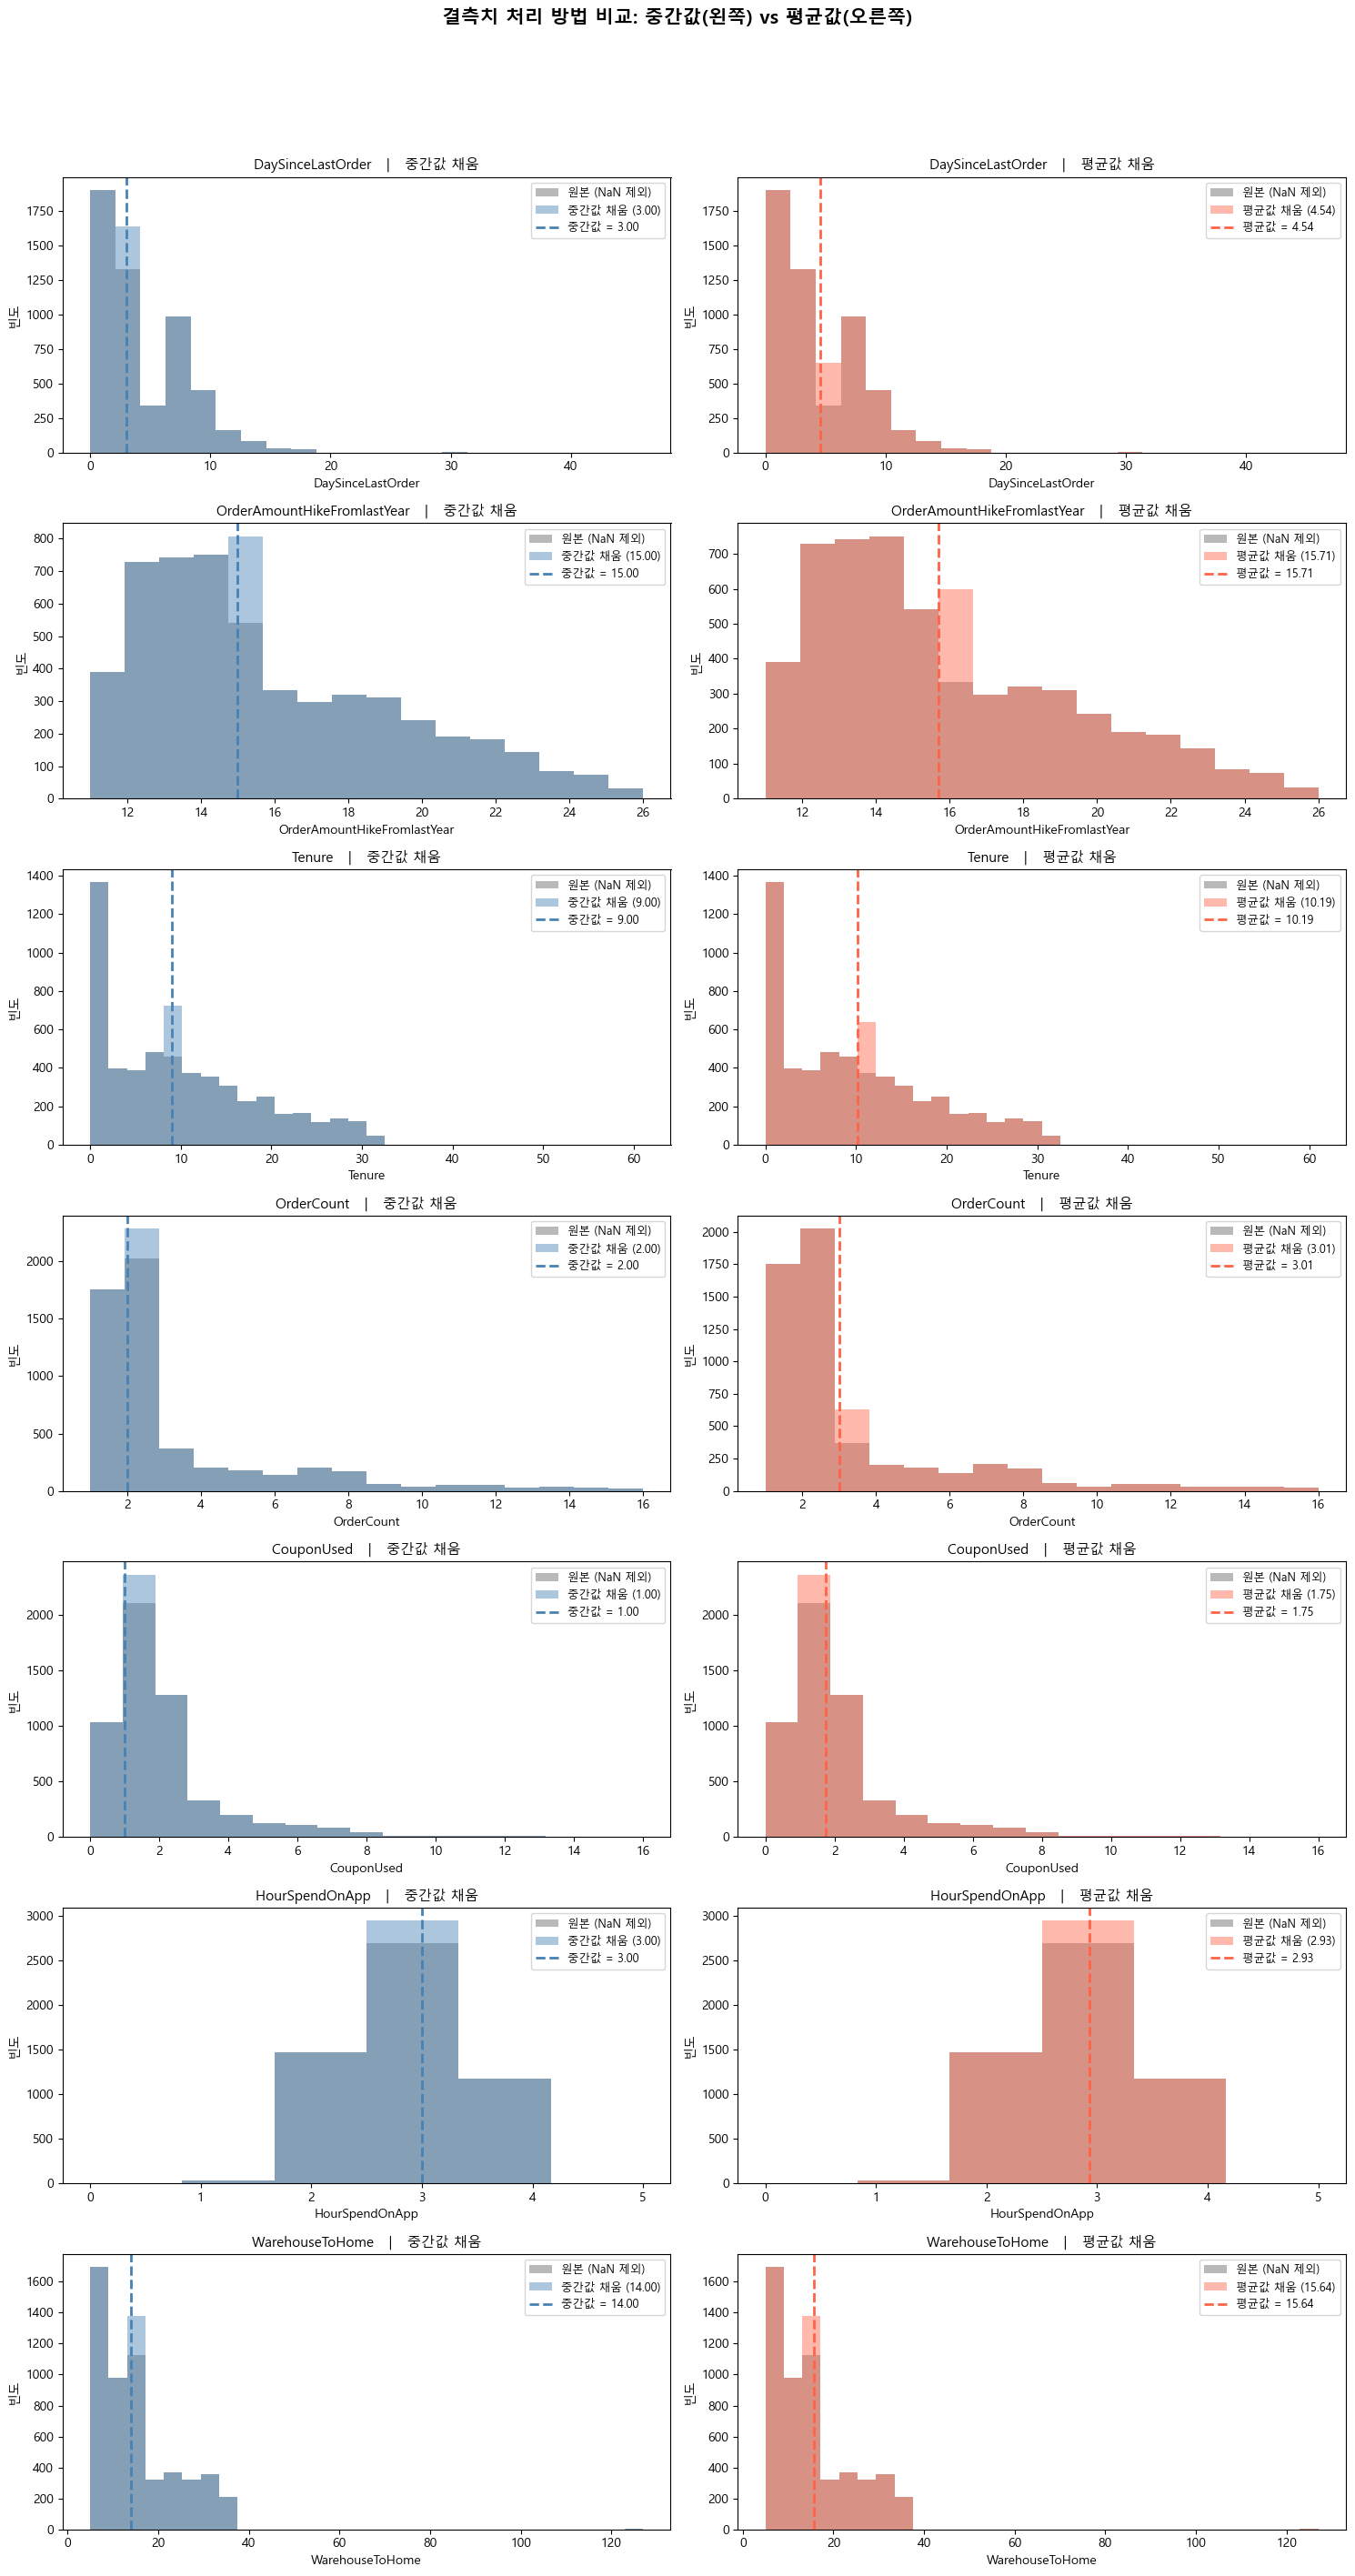


💡 판단 기준:
   - 분포가 대칭(정규분포)에 가깝다면 → 평균값(mean)이 적합
   - 분포가 한쪽으로 치우쳐 있거나 이상치가 있다면 → 중간값(median)이 안전



,결측치 수,중간값,평균값,왜도(skewness),권장
DaySinceLastOrder,307,3.000000,4.540000,1.190000,중간값 권장 (|왜도|>0.5)
OrderAmountHikeFromlastYear,265,15.000000,15.710000,0.790000,중간값 권장 (|왜도|>0.5)
Tenure,264,9.000000,10.190000,0.740000,중간값 권장 (|왜도|>0.5)
OrderCount,258,2.000000,3.010000,2.200000,중간값 권장 (|왜도|>0.5)
CouponUsed,256,1.000000,1.750000,2.550000,중간값 권장 (|왜도|>0.5)
HourSpendOnApp,255,3.000000,2.930000,-0.030000,평균값 권장
WarehouseToHome,251,14.000000,15.640000,1.620000,중간값 권장 (|왜도|>0.5)


In [7]:
# ─────────────────────────────────────────────
# 2. 결측치 방법 비교 (중간값 vs 평균)
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# 결측치가 있는 컬럼 목록
missing_cols = [
    "DaySinceLastOrder",
    "OrderAmountHikeFromlastYear",
    "Tenure",
    "OrderCount",
    "CouponUsed",
    "HourSpendOnApp",
    "WarehouseToHome"
]

n = len(missing_cols)
fig, axes = plt.subplots(n, 2, figsize=(15, 4 * n))
fig.suptitle("결측치 처리 방법 비교: 중간값(왼쪽) vs 평균값(오른쪽)", fontsize=15, fontweight="bold", y=1.01)

for i, col in enumerate(missing_cols):
    original   = df[col].dropna()
    median_val = df[col].median()
    mean_val   = df[col].mean()

    filled_median = df[col].fillna(median_val)
    filled_mean   = df[col].fillna(mean_val)

    bins = min(30, int(df[col].nunique()))
    bin_edges_m = np.histogram_bin_edges(filled_median, bins=bins)
    bin_edges_n = np.histogram_bin_edges(filled_mean,   bins=bins)

    # ── 왼쪽: 중간값 채움 ──
    ax_l = axes[i, 0]
    ax_l.hist(original,      bins=bin_edges_m, alpha=0.55, color="gray",     label="원본 (NaN 제외)")
    ax_l.hist(filled_median, bins=bin_edges_m, alpha=0.45, color="steelblue", label=f"중간값 채움 ({median_val:.2f})")
    ax_l.axvline(median_val, color="steelblue", linestyle="--", linewidth=2, label=f"중간값 = {median_val:.2f}")
    ax_l.set_title(f"{col}  ┃  중간값 채움", fontsize=11)
    ax_l.set_xlabel(col)
    ax_l.set_ylabel("빈도")
    ax_l.legend(fontsize=9)

    # ── 오른쪽: 평균값 채움 ──
    ax_r = axes[i, 1]
    ax_r.hist(original,    bins=bin_edges_n, alpha=0.55, color="gray",   label="원본 (NaN 제외)")
    ax_r.hist(filled_mean, bins=bin_edges_n, alpha=0.45, color="tomato", label=f"평균값 채움 ({mean_val:.2f})")
    ax_r.axvline(mean_val, color="tomato", linestyle="--", linewidth=2, label=f"평균값 = {mean_val:.2f}")
    ax_r.set_title(f"{col}  ┃  평균값 채움", fontsize=11)
    ax_r.set_xlabel(col)
    ax_r.set_ylabel("빈도")
    ax_r.legend(fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
print("\n💡 판단 기준:")
print("   - 분포가 대칭(정규분포)에 가깝다면 → 평균값(mean)이 적합")
print("   - 분포가 한쪽으로 치우쳐 있거나 이상치가 있다면 → 중간값(median)이 안전")
print()

# 요약 테이블 출력
summary = pd.DataFrame({
    "결측치 수": df[missing_cols].isnull().sum(),
    "중간값": df[missing_cols].median().round(2),
    "평균값": df[missing_cols].mean().round(2),
    "왜도(skewness)": df[missing_cols].skew().round(2)
})
summary["권장"] = summary["왜도(skewness)"].apply(
    lambda s: "중간값 권장 (|왜도|>0.5)" if abs(s) > 0.5 else "평균값 권장"
)
# 많이 치우쳐진 CouponUsed, OrderCount는 결측치 처리 후, 로그 변환 예정

display(summary.style.set_properties(**{'text-align': 'left'})
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

In [8]:
# ─────────────────────────────────────────────
# 3. 결측치 채우기
# ─────────────────────────────────────────────
# 위에 표에 따라 결측치 채움
fill_method = "median"   # ← 원하는 방법으로 변경하세요

for col in missing_cols:
    if col == "HourSpendOnApp":
        # 이 컬럼은 설정과 상관없이 무조건 평균값 적용
        df[col] = df[col].fillna(df[col].mean())
        print(f"- {col:30s}: 평균값(mean)적용")
    else:
        # 나머지 컬럼은 기본 설정된 방법(median) 적용
        if fill_method == "median":
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mean())
        print(f"- {col:30s}: 중간값(median)적용")

remaining = df[missing_cols].isnull().sum().sum()
print(f"\n✅ 결측치 채움 완료")
print(f"   남은 결측치: {remaining}개")

- DaySinceLastOrder             : 중간값(median)적용
- OrderAmountHikeFromlastYear   : 중간값(median)적용
- Tenure                        : 중간값(median)적용
- OrderCount                    : 중간값(median)적용
- CouponUsed                    : 중간값(median)적용
- HourSpendOnApp                : 평균값(mean)적용
- WarehouseToHome               : 중간값(median)적용

✅ 결측치 채움 완료
   남은 결측치: 0개


In [9]:
# ─────────────────────────────────────────────
# 4. OrderCount와 CouponUsed는 로그변환(왜도줄여 데이터 분포를 정규화, 이상치 영향을 완화)
# ─────────────────────────────────────────────
df['OrderCount_log'] = np.log1p(df['OrderCount'])
df['CouponUsed_log'] = np.log1p(df['CouponUsed'])

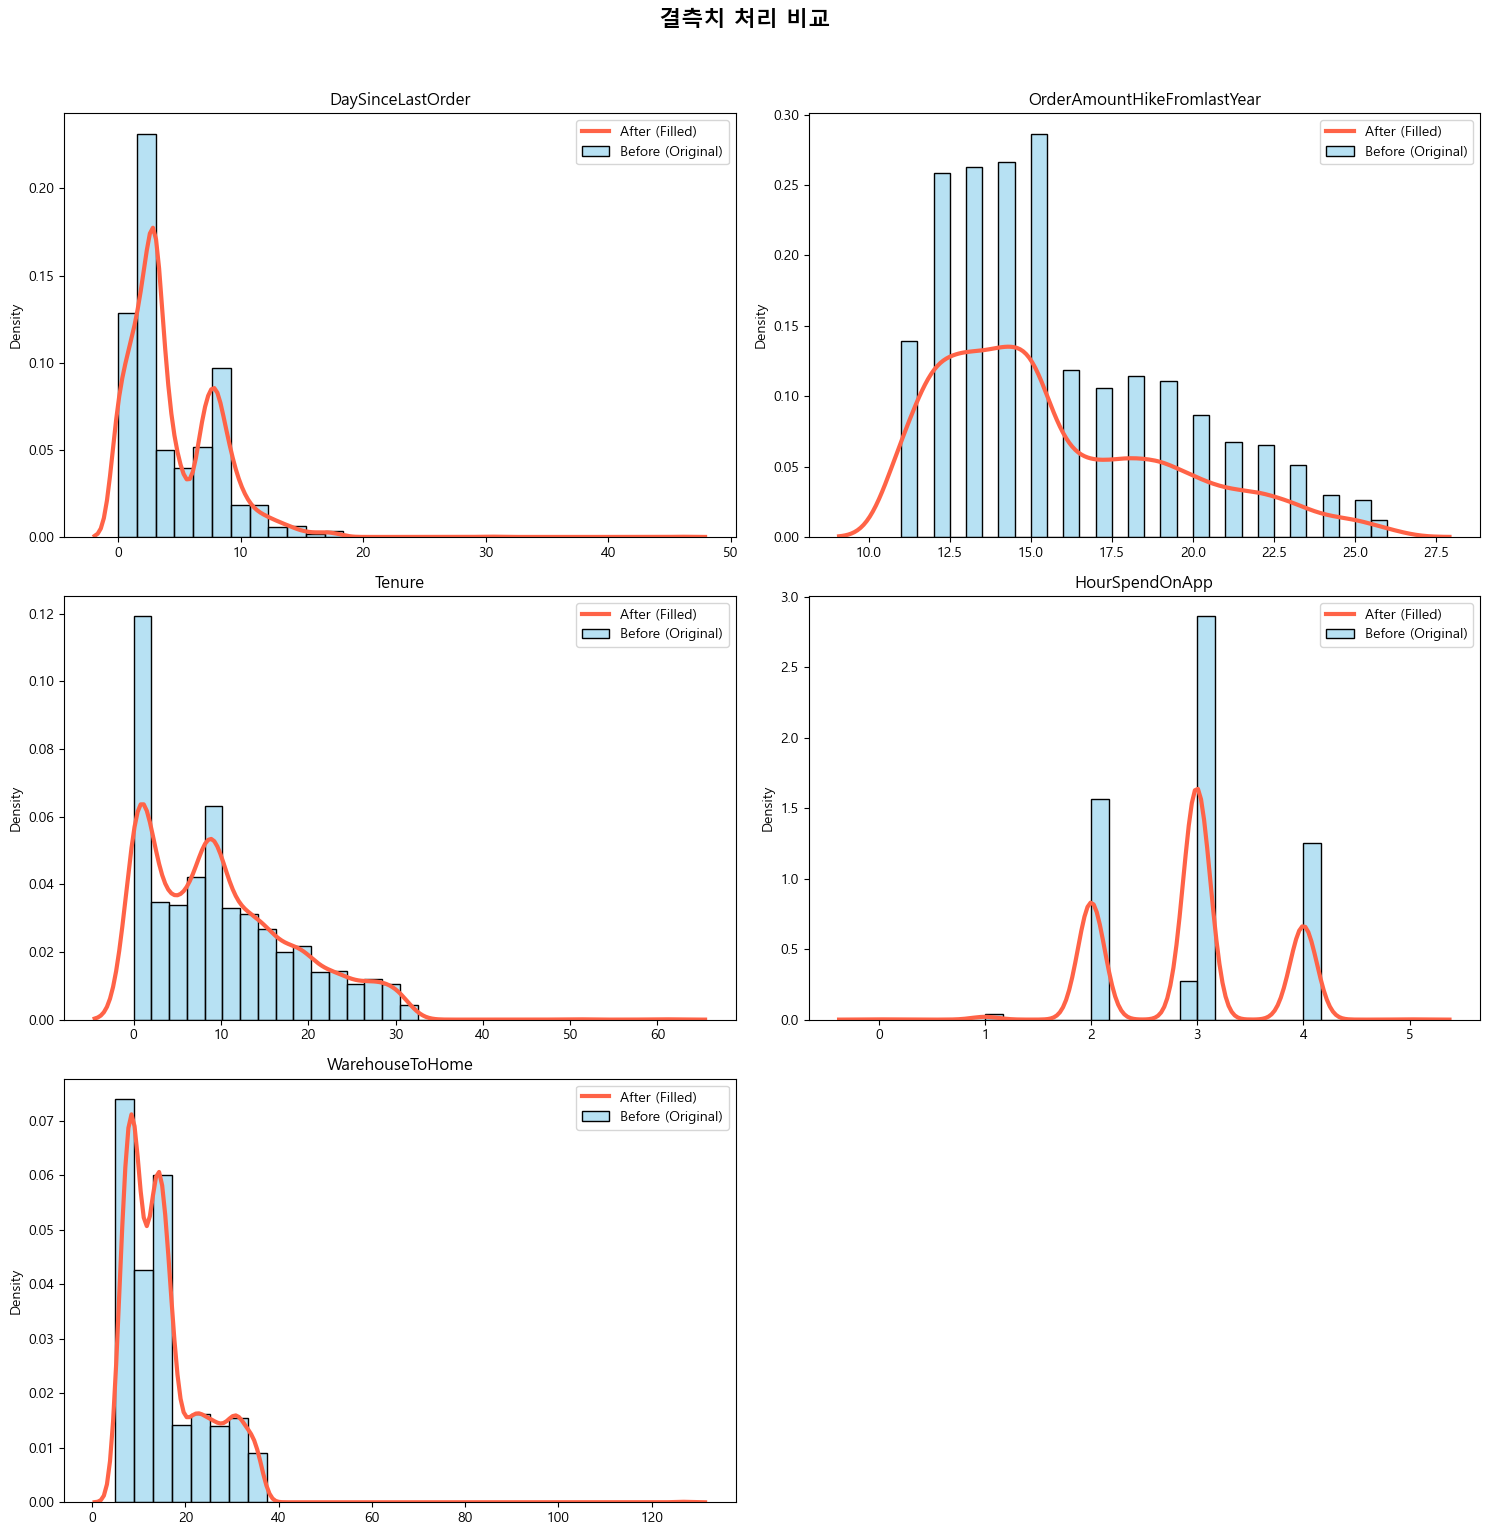

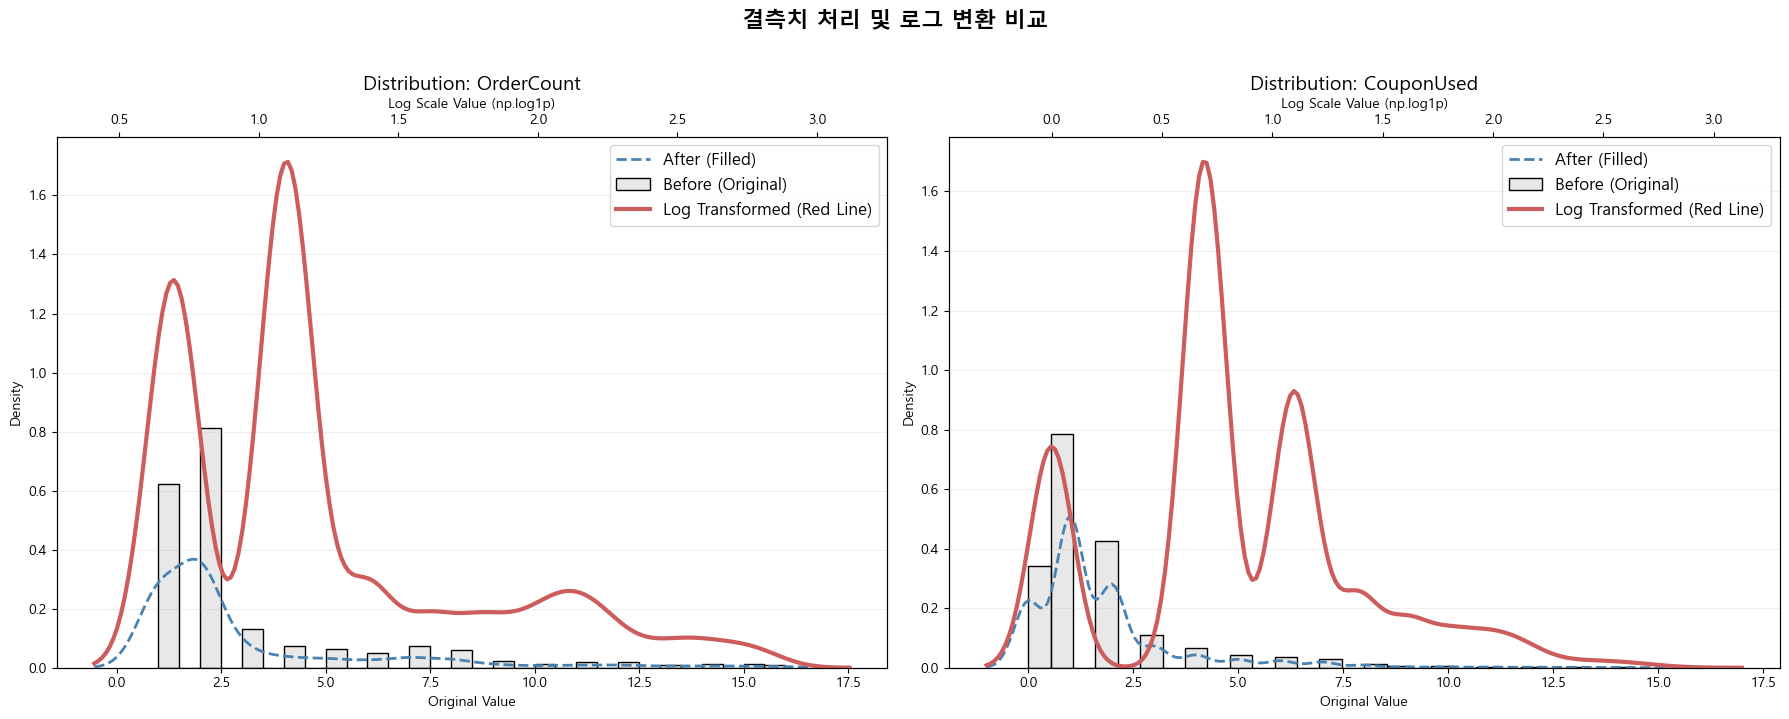

In [10]:
# ─────────────────────────────────────────────
# 5. 결측치 처리 전,후 시각화
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

log_target_cols = ['OrderCount', 'CouponUsed']
simple_cols = [col for col in missing_cols if col not in log_target_cols]

n_cols = 2
n_rows = (len(simple_cols) + 1) // n_cols

# ──────────로그 변환 대상 제외한 나머지 5개 컬럼 추출──────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
fig.suptitle("결측치 처리 비교", fontsize=16, fontweight='bold', y=1.02)

axes = axes.flatten()

for i, col in enumerate(simple_cols):
    # Before: 원본 데이터 (막대)
    sns.histplot(df[col].dropna(), bins=30, kde=False, ax=axes[i], 
                 color='skyblue', label='Before (Original)', stat="density", alpha=0.6)
    
    # After: 결측치 처리 후 (선)
    sns.kdeplot(df[col], ax=axes[i], color='tomato', 
                linewidth=3, label='After (Filled)')
    
    axes[i].set_title(f"{col}")
    axes[i].legend(loc='upper right')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

# 빈 칸 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#─────────────OrderCount, CouponUsed─────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("결측치 처리 및 로그 변환 비교", fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(log_target_cols):
    ax1 = axes[i]
    
    # 1. 원본 (회색 막대)
    sns.histplot(df[col].dropna(), bins=30, kde=False, ax=ax1, 
                 color='lightgray', label='Before (Original)', stat='density', alpha=0.5)
    
    # 2. 결측치 처리 후 (파란 점선)
    sns.kdeplot(df[col], ax=ax1, color='steelblue', 
                linewidth=2, label='After (Filled)', linestyle='--')
    
    ax1.set_title(label=f'Distribution: {col}', fontsize=14)
    ax1.set_xlabel(xlabel='Original Value')
    ax1.set_ylabel(ylabel='Density')

    # 3. 로그 변환 후 (빨간 실선, 상단 X축 사용)
    ax2 = ax1.twiny()
    log_col = f'{col}_log'
    sns.kdeplot(df[log_col], ax=ax2, color='indianred', 
                linewidth=3, label='Log Transformed (Red Line)')
    
    ax2.set_xlabel(xlabel='Log Scale Value (np.log1p)')
    
    # ── 범례 합치기 핵심 로직 ──
    # ax1과 ax2의 모든 핸들과 라벨을 가져와서 하나로 합칩니다.
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=12)
    
    ax1.grid(visible=True, axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 2. 중복 데이터 확인

In [11]:
# ─────────────────────────────────────────────
# 4. 중복 데이터 확인
# ─────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"\n🔍 전체 중복 행 수: {dup_count}개")

# CustomerID 기준 중복 확인
dup_id_count = df.duplicated(subset=["CustomerID"]).sum()
print(f"🔍 CustomerID 기준 중복 행 수: {dup_id_count}개")

if dup_count == 0 and dup_id_count == 0:
    print("✅ 중복 데이터 없음")


🔍 전체 중복 행 수: 0개
🔍 CustomerID 기준 중복 행 수: 0개
✅ 중복 데이터 없음


## 3. 범주형 데이터 통합 및 정제


In [12]:
# ─────────────────────────────────────────────
# 5. 범주형 데이터 통합 및 정제
# ─────────────────────────────────────────────

print("정제 전 고유값:")
print(f"  PreferredLoginDevice : {sorted(df['PreferredLoginDevice'].unique())}")
print(f"  PreferedOrderCat     : {sorted(df['PreferedOrderCat'].unique())}")
print(f"  PreferredPaymentMode : {sorted(df['PreferredPaymentMode'].unique())}")

# ── PreferredLoginDevice: Mobile Phone → Phone 으로 통일 ─────────────
df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Mobile Phone": "Phone"})

# ── PreferedOrderCat: Mobile Phone → Mobile 으로 통일 ────────────────
df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({"Mobile Phone": "Mobile"})

# ── PreferredPaymentMode: 중복 표기 통일 ─────────────────────────────
#    COD + Cash on Delivery → "COD"         (약어로 통일)
#    CC  + Credit Card      → "Credit Card" (정식 명칭으로 통일)
#    최종 5종: COD / Credit Card / Debit Card / E wallet / UPI
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({
    "Cash on Delivery": "COD",
    "CC"              : "Credit Card",
})

print("\n정제 후 고유값:")
print(f"  PreferredLoginDevice : {sorted(df['PreferredLoginDevice'].unique())}")
print(f"  PreferedOrderCat     : {sorted(df['PreferedOrderCat'].unique())}")
print(f"  PreferredPaymentMode : {sorted(df['PreferredPaymentMode'].unique())}")
print("\n✅ 카테고리 정제 완료")


정제 전 고유값:
  PreferredLoginDevice : ['Computer', 'Mobile Phone', 'Phone']
  PreferedOrderCat     : ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others']
  PreferredPaymentMode : ['CC', 'COD', 'Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']

정제 후 고유값:
  PreferredLoginDevice : ['Computer', 'Phone']
  PreferedOrderCat     : ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Others']
  PreferredPaymentMode : ['COD', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']

✅ 카테고리 정제 완료


In [13]:
# ─────────────────────────────────────────────
# 6. 범주형 -> 수치화 
# ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    "PreferredLoginDevice",  # Computer / Phone
    "PreferredPaymentMode",  # Cash on Delivery / Credit Card / Debit Card / E wallet / UPI
    "Gender",                # Female / Male
    "PreferedOrderCat",      # Fashion / Grocery / Laptop & Accessory / Mobile / Others
    "MaritalStatus",         # Divorced / Married / Single
]

# Before: 원본 데이터 (범주형 포함, df 보존) 
print("=" * 65)
print("Before — 원본 데이터 (범주형 포함, df 유지)")
print("=" * 65)

display(df[["CustomerID"] + cat_cols].head(5).style.set_properties(**{'text-align': 'left'})
                    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
print(f"\n원본 전체 컬럼 수: {df.shape[1]}개  |  데이터 크기: {df.shape}")


# Label Encoding → df_encoded (df 복사본, 컬럼 수 동일)
df_encoded = df.drop(columns=["OrderCount", "CouponUsed"])  # 원본 df는 그대로 유지
label_encoders = {}
encoding_map   = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    encoding_map[col]   = dict(zip(le.classes_, le.transform(le.classes_).tolist()))


# After: 수치형 변환 데이터
print("\n" + "=" * 65)
print("After  — 수치형 변환 데이터 (df_encoded, 컬럼 수 동일)")
print("=" * 65)

display(df_encoded[["CustomerID"] + cat_cols].head(5).style.set_properties(**{'text-align': 'left'})
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
print(f"\n컬럼 수: {df_encoded.shape[1]}개  |  데이터 크기: {df_encoded.shape}")

print()
print("\n📋 인코딩 매핑:")
for col, mapping in encoding_map.items():
    print(f"  {col:30s}: {mapping}")

Before — 원본 데이터 (범주형 포함, df 유지)


,CustomerID,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,50001,Phone,Debit Card,Female,Laptop & Accessory,Single
1,50002,Phone,UPI,Male,Mobile,Single
2,50003,Phone,Debit Card,Male,Mobile,Single
3,50004,Phone,Debit Card,Male,Laptop & Accessory,Single
4,50005,Phone,Credit Card,Male,Mobile,Single



원본 전체 컬럼 수: 22개  |  데이터 크기: (5630, 22)

After  — 수치형 변환 데이터 (df_encoded, 컬럼 수 동일)


,CustomerID,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,50001,1,2,0,2,2
1,50002,1,4,1,3,2
2,50003,1,2,1,3,2
3,50004,1,2,1,2,2
4,50005,1,1,1,3,2



컬럼 수: 20개  |  데이터 크기: (5630, 20)


📋 인코딩 매핑:
  PreferredLoginDevice          : {'Computer': 0, 'Phone': 1}
  PreferredPaymentMode          : {'COD': 0, 'Credit Card': 1, 'Debit Card': 2, 'E wallet': 3, 'UPI': 4}
  Gender                        : {'Female': 0, 'Male': 1}
  PreferedOrderCat              : {'Fashion': 0, 'Grocery': 1, 'Laptop & Accessory': 2, 'Mobile': 3, 'Others': 4}
  MaritalStatus                 : {'Divorced': 0, 'Married': 1, 'Single': 2}


## 4. 이상치

이탈(Churn=1) 고객과 유지(Churn=0) 고객 사이에서 이상치가 어떤 의미를 갖는지 분석합니다.  
**핵심 질문:** 이상치가 이탈을 예측하는 정보를 담고 있는가? → 제거 vs 유지 결정의 근거

'전체 이탈률: 0.1684 (16.8%)'

,이상치 수,비율(%),이상치 이탈률,정상 이탈률,차이,판단
피처,,,,,,
Tenure,4,0.070000,0.000000,0.168500,-0.168500,★ 정보성 (유지 권장)
PreferredLoginDevice,0,0.000000,0.000000,0.168400,-0.168400,★ 정보성 (유지 권장)
CityTier,0,0.000000,0.000000,0.168400,-0.168400,★ 정보성 (유지 권장)
WarehouseToHome,2,0.040000,0.000000,0.168400,-0.168400,★ 정보성 (유지 권장)
PreferredPaymentMode,414,7.350000,0.173900,0.167900,0.006000,▲ 분포왜곡 (변환 권장)
Gender,0,0.000000,0.000000,0.168400,-0.168400,★ 정보성 (유지 권장)
HourSpendOnApp,6,0.110000,0.000000,0.168600,-0.168600,★ 정보성 (유지 권장)
NumberOfDeviceRegistered,397,7.050000,0.196500,0.166300,0.030200,▲ 분포왜곡 (변환 권장)
PreferedOrderCat,826,14.670000,0.155000,0.170700,-0.015700,▲ 분포왜곡 (변환 권장)


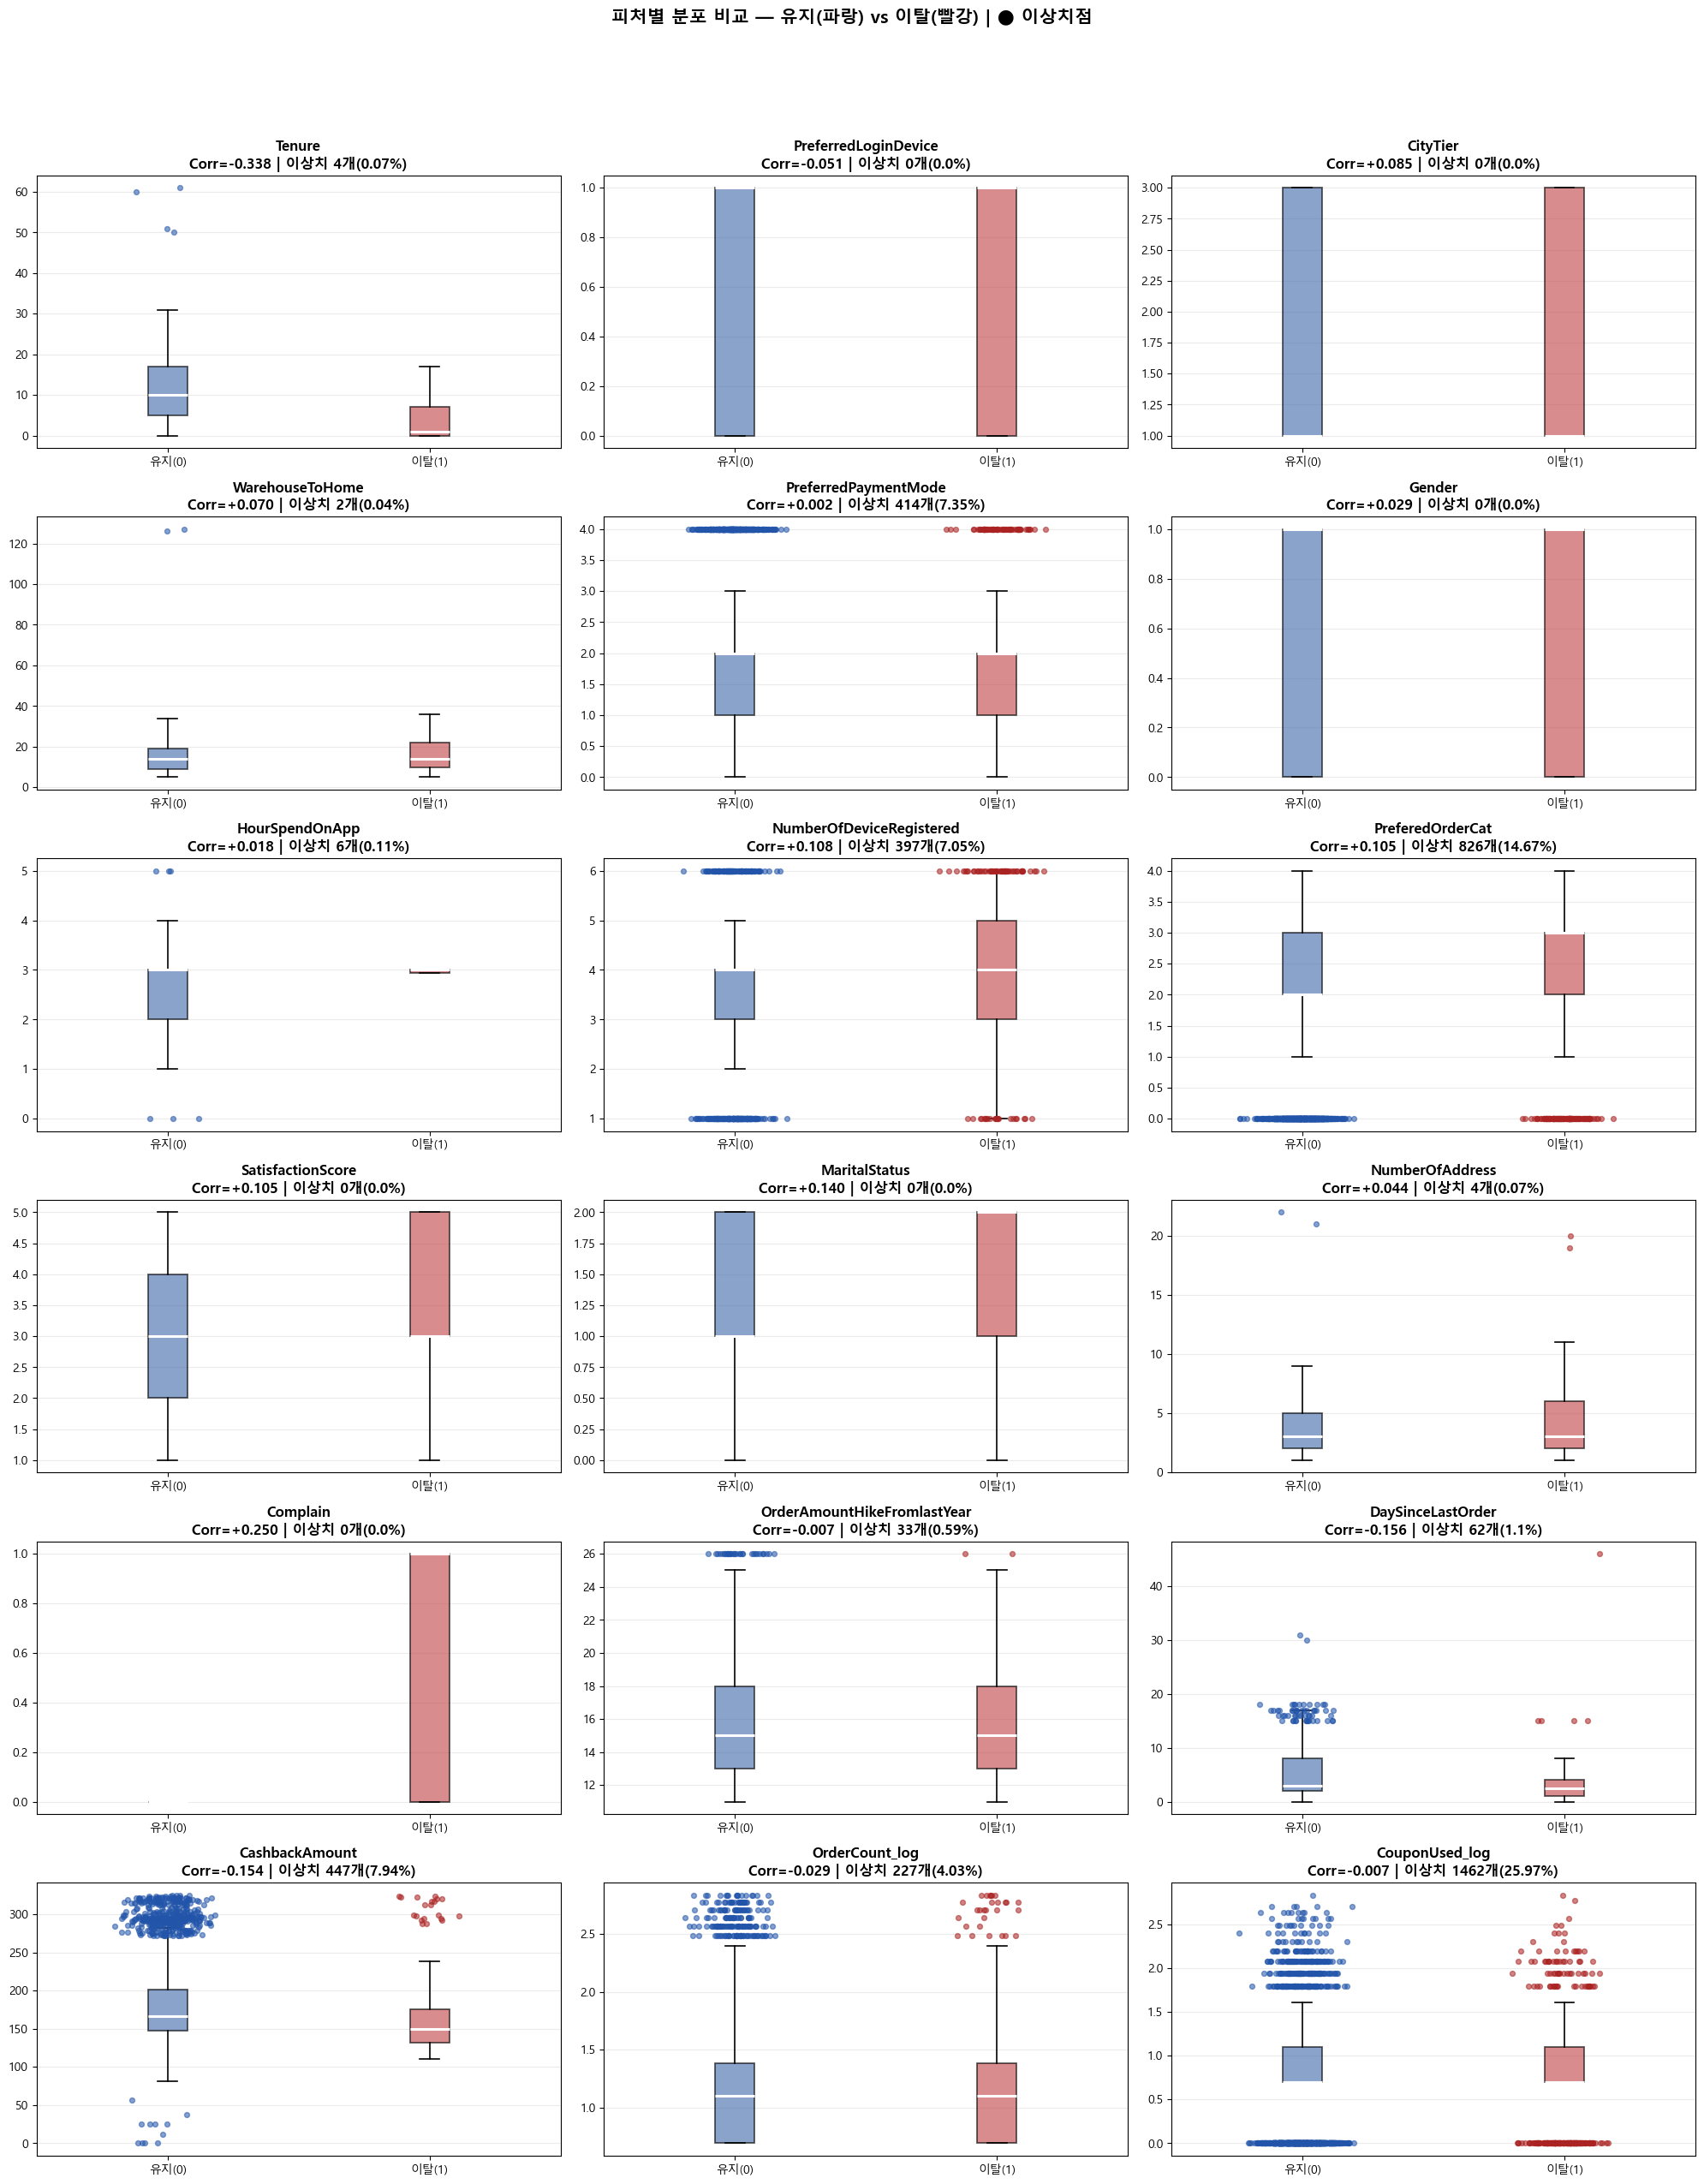

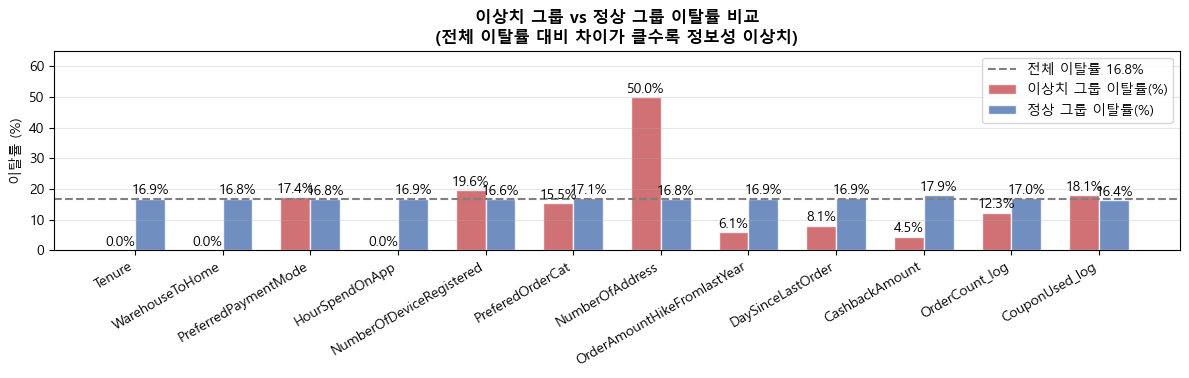

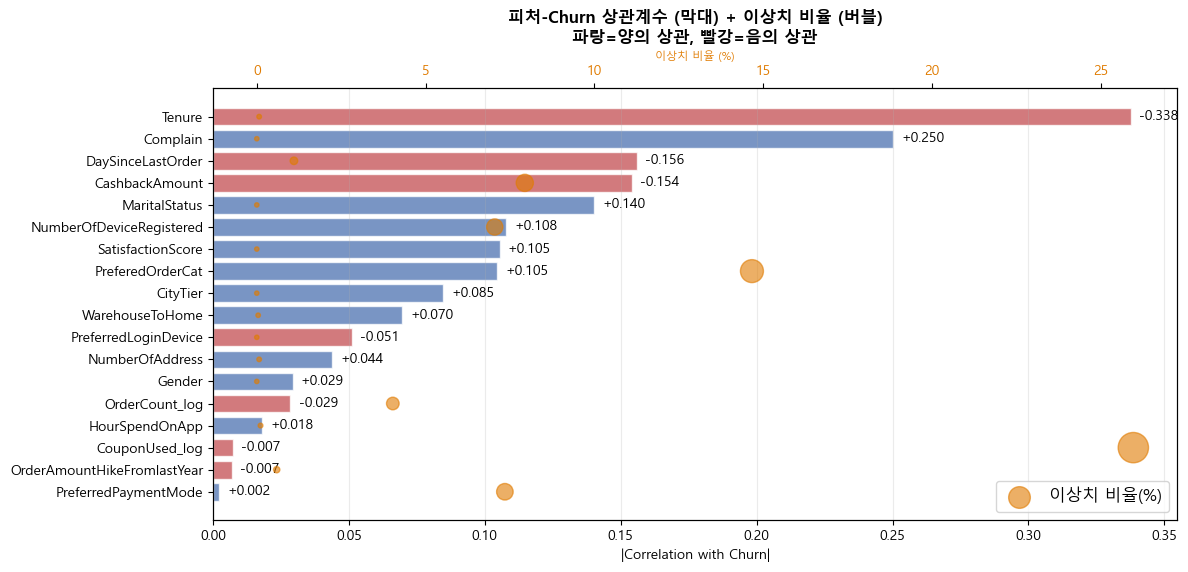

In [14]:
import matplotlib.pyplot as plt  
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")

exclude = {'Churn', 'CustomerID'}  # 제외할 컬럼 추가
num_cols = [col for col in df_encoded.select_dtypes(include='number').columns
            if col not in exclude]
overall_churn = df_encoded["Churn"].mean()

# ── IQR + 이탈률 계산 ────────────────────────────────────────────────
outlier_info = {}
for col in num_cols:
    Q1, Q3  = df_encoded[col].quantile(0.25), df_encoded[col].quantile(0.75)
    IQR     = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    mask    = (df_encoded[col] < lower) | (df_encoded[col] > upper)
    n_out   = int(mask.sum())
    out_churn  = df_encoded.loc[mask,  "Churn"].mean() if n_out > 0 else 0.0
    norm_churn = df_encoded.loc[~mask, "Churn"].mean()
    diff       = out_churn - norm_churn
    outlier_info[col] = dict(Q1=Q1, Q3=Q3, IQR=IQR, lower=lower, upper=upper,
                             n_out=n_out, pct=round(n_out/len(df_encoded)*100,2),
                             out_churn=out_churn, norm_churn=norm_churn, diff=diff,
                             mask=mask)

# 피처-Churn 상관계수
corr_vals = df_encoded[num_cols + ["Churn"]].corr()["Churn"].drop("Churn")

# ── 요약 테이블 출력 ─────────────────────────────────────────────────
rows = []
for col in num_cols:
    v = outlier_info[col]
    if abs(v["diff"]) > 0.05:
        tag = "★ 정보성 (유지 권장)"
    elif v["n_out"] > 200:
        tag = "▲ 분포왜곡 (변환 권장)"
    else:
        tag = "○ 소량/무관"
    rows.append({
        "피처": col,
        "이상치 수": v["n_out"],
        "비율(%)": v["pct"],
        "이상치 이탈률": round(v["out_churn"], 4),
        "정상 이탈률": round(v["norm_churn"], 4),
        "차이": round(v["diff"], 4),
        "판단": tag
    })

display(f"전체 이탈률: {overall_churn:.4f} ({overall_churn*100:.1f}%)")
display(pd.DataFrame(rows).set_index("피처")
        .style.set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

# ════════════════════════════════════════════════════════════════════
# 【Fig 1】 Churn별 피처 분포 비교 (이탈=빨강 / 유지=파랑)
# ════════════════════════════════════════════════════════════════════
N_COLS, N_ROWS = 3, -(-len(num_cols) // 3)
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(20, N_ROWS * 4.2))
fig.suptitle("피처별 분포 비교 — 유지(파랑) vs 이탈(빨강) | ● 이상치점",
             fontsize=15, fontweight="bold", y=1.01)
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    ax   = axes_flat[i]
    info = outlier_info[col]
    g0 = df_encoded[df_encoded["Churn"]==0][col]
    g1 = df_encoded[df_encoded["Churn"]==1][col]

    bp = ax.boxplot([g0, g1], patch_artist=True, labels=["유지(0)","이탈(1)"],
                    showfliers=False,
                    boxprops=dict(linewidth=1.3),
                    medianprops=dict(linewidth=2.2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    bp["boxes"][0].set_facecolor("#4C72B0"); bp["boxes"][0].set_alpha(0.65)
    bp["boxes"][1].set_facecolor("#C44E52"); bp["boxes"][1].set_alpha(0.65)
    bp["medians"][0].set_color("white")
    bp["medians"][1].set_color("white")

    # 이상치 점 overlay (원본 IQR 경계 기준)
    for j, (gdata, color) in enumerate([(g0,"#2255AA"),(g1,"#AA2222")], start=1):
        mask_g = (gdata < info["lower"]) | (gdata > info["upper"])
        outs   = gdata[mask_g]
        ax.scatter(np.random.normal(j, 0.07, size=len(outs)), outs,
                   color=color, s=18, alpha=0.55, zorder=4)

    corr_v = corr_vals[col]
    ax.set_title(f"{col}\nCorr={corr_v:+.3f} | 이상치 {info['n_out']}개({info['pct']}%)",
                 fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

for j in range(len(num_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ════════════════════════════════════════════════════════════════════
# 【Fig 2】 이상치 이탈률 vs 정상 이탈률 비교 바 차트
# ════════════════════════════════════════════════════════════════════
# 이상치 있는 컬럼만 추출
has_out = [(col, outlier_info[col]) for col in num_cols if outlier_info[col]["n_out"] > 0]
labels  = [c for c,_ in has_out]
out_rates  = [v["out_churn"]*100 for _,v in has_out]
norm_rates = [v["norm_churn"]*100 for _,v in has_out]

x     = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(12, 4))
b1 = ax.bar(x - width/2, out_rates,  width, label="이상치 그룹 이탈률(%)", color="#C44E52", alpha=0.8, edgecolor="white")
b2 = ax.bar(x + width/2, norm_rates, width, label="정상 그룹 이탈률(%)",   color="#4C72B0", alpha=0.8, edgecolor="white")
ax.axhline(overall_churn*100, color="gray", linestyle="--", linewidth=1.5,
           label=f"전체 이탈률 {overall_churn*100:.1f}%")

for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("이탈률 (%)"); ax.set_ylim(0, 65)
ax.set_title("이상치 그룹 vs 정상 그룹 이탈률 비교\n(전체 이탈률 대비 차이가 클수록 정보성 이상치)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ════════════════════════════════════════════════════════════════════
# 【Fig 3】 피처-Churn 상관계수 + 이상치 비율 (버블 차트)
# ════════════════════════════════════════════════════════════════════
corr_sorted = corr_vals.abs().sort_values(ascending=True)
pct_vals    = [outlier_info[col]["pct"] for col in corr_sorted.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ["#C44E52" if corr_vals[c] < 0 else "#4C72B0" for c in corr_sorted.index]
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colors_bar, alpha=0.75, edgecolor="white")

# 이상치 비율 버블 overlay
ax2 = ax.twiny()
ax2.scatter(pct_vals, range(len(corr_sorted)),
            s=[p*18+10 for p in pct_vals], color="#E07B00", alpha=0.6,
            label="이상치 비율(%)", zorder=5)
ax2.set_xlabel("이상치 비율 (%)", color="#E07B00", fontsize=8)
ax2.tick_params(axis="x", labelcolor="#E07B00")
ax2.legend(loc="lower right", fontsize=12)

for bar, val, col in zip(bars, corr_sorted.values, corr_sorted.index):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f"{corr_vals[col]:+.3f}", va="center", fontsize=10)

ax.set_xlabel("|Correlation with Churn|", fontsize=10)
ax.set_title("피처-Churn 상관계수 (막대) + 이상치 비율 (버블)\n파랑=양의 상관, 빨강=음의 상관",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [15]:
# ─────────────────────────────────────────────
# 스케일링 처리 (로그변환 컬럼 대상)
# ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scale_cols = ["OrderCount_log", "CouponUsed_log"]
scaler = StandardScaler()

df_encoded_scaled = df_encoded.copy()
df_encoded_scaled[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

print("✅스케일링 완료")
display(df_encoded_scaled[scale_cols].describe().round(4))

✅스케일링 완료


,OrderCount_log,CouponUsed_log
count,5630.0000,5630.0000
mean,0.0000,0.0000
std,1.0001,1.0001
min,-0.9652,-1.5101
25%,-0.9652,-0.2548
50%,-0.2020,-0.2548
75%,0.3395,0.4795
max,3.0631,3.6209


## 📊 변수 간 상관관계 분석

**분석 목적:**
- 고객 이탈(Churn)과 각 변수 간의 상관관계를 파악
- 변수들 간의 다중공선성(Multicollinearity) 문제 탐지
- 상관관계가 높은 변수들을 그룹으로 묶어 해석

1. 상관관계 히트맵 : 피처 간 상관관계 + Churn과의 상관관계
2. Churn 상관관계 바 차트 : Churn과의 상관관계 정렬


### 상관관계 해석 가이드

| 상관계수 범위 | 해석 | 조치 |
|---|---|---|
| \|r\| < 0.1 | 거의 무관 | 그대로 사용 |
| 0.1 ≤ \|r\| < 0.3 | 약한 상관 | 고려 |
| 0.3 ≤ \|r\| < 0.5 | 중간 상관 | 주의, 그룹핑 고려 |
| 0.5 ≤ \|r\| < 0.7 | 강한 상관 | 다중공선성 의심 |
| \|r\| ≥ 0.7 | 매우 강한 상관 | 제거 또는 그룹화 권장 |

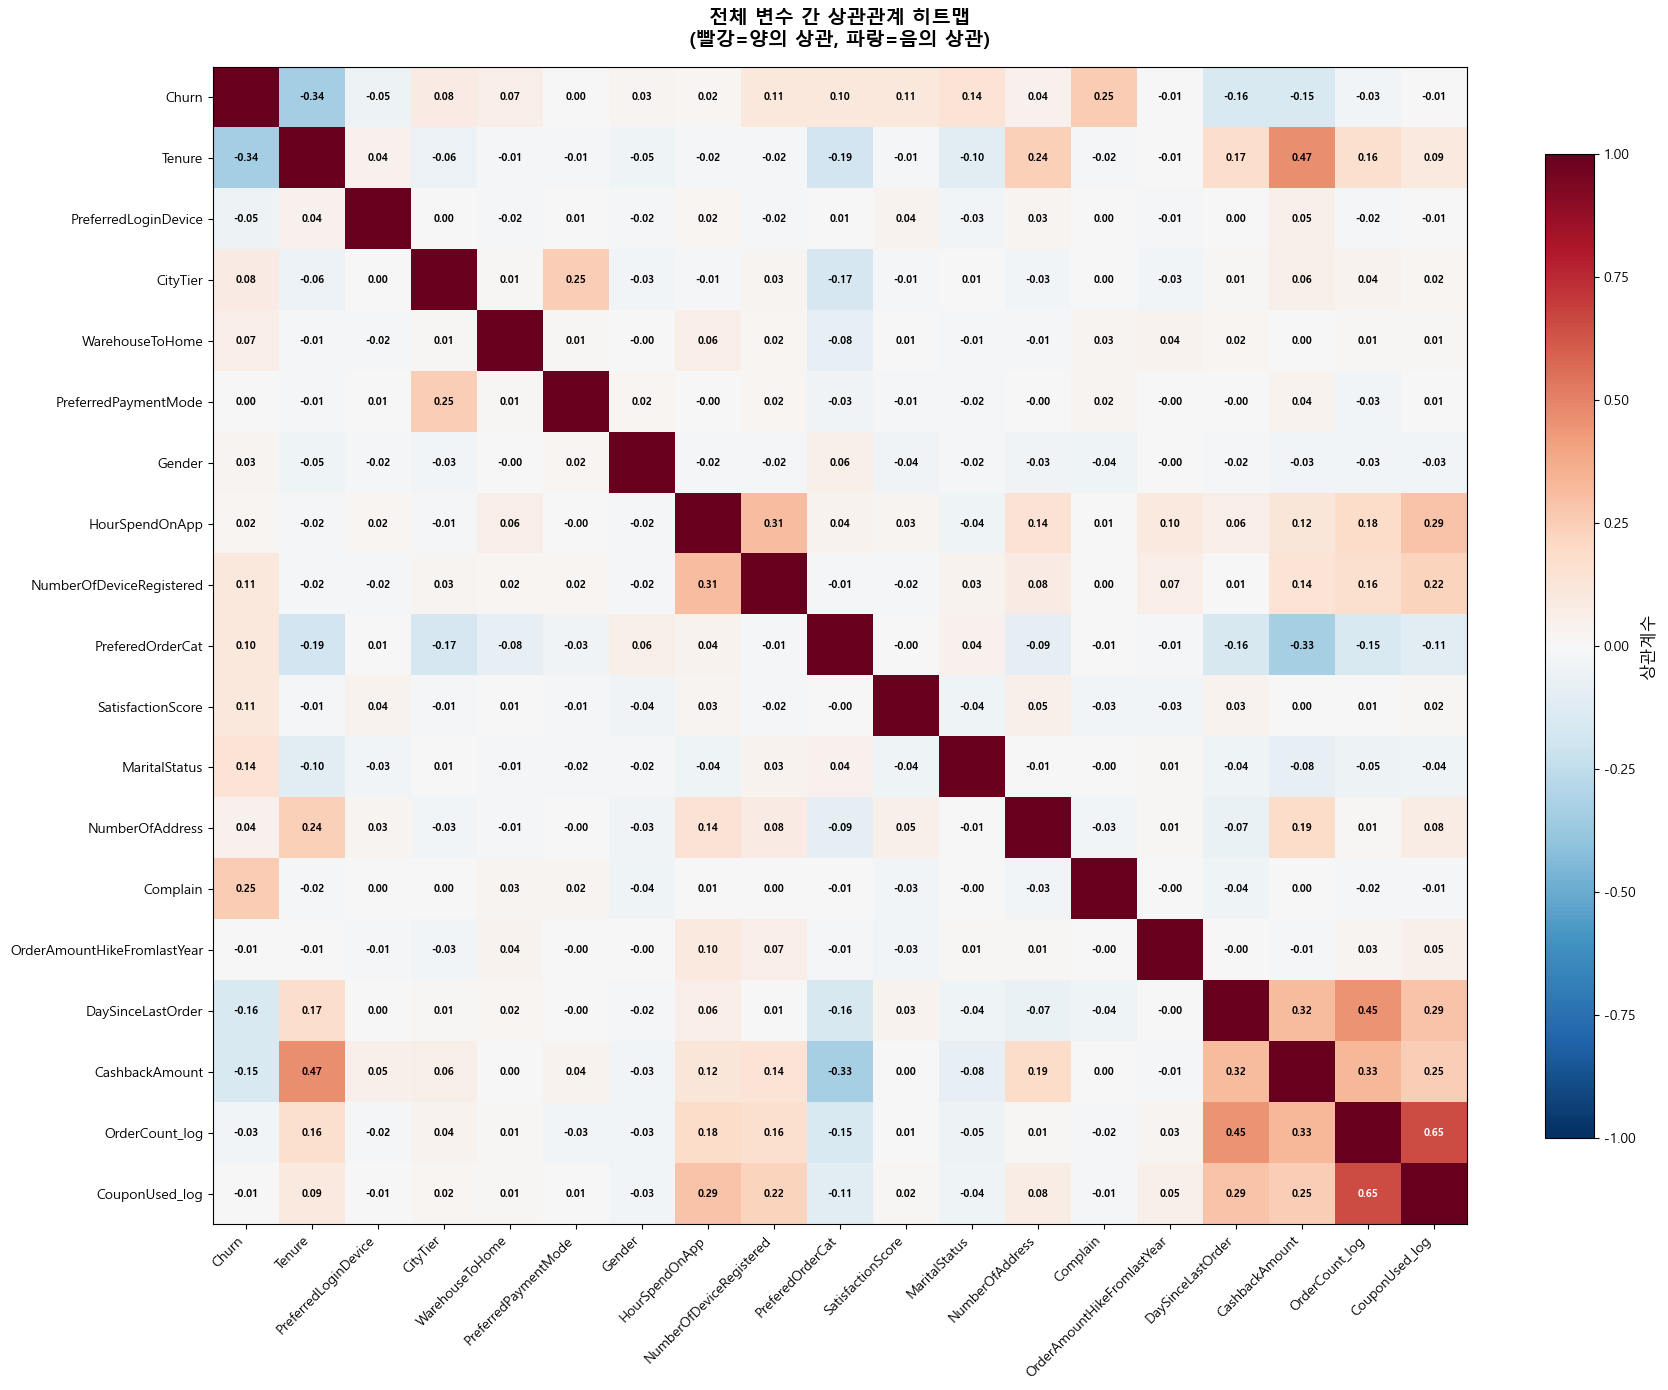

In [16]:
import pandas as pd
# ════════════════════════════════════════════════════════════════════
# 【Fig 1 — 상관관계 히트맵】 피처 간 상관관계 + Churn과의 상관관계
# ════════════════════════════════════════════════════════════════════

# 분석 대상: CustomerID 제외, 전체 수치형 변수
analysis_cols = [col for col in df_encoded_scaled.columns if col != "CustomerID"]
corr_matrix = df_encoded_scaled[analysis_cols].corr()

# ── 1) 전체 상관관계 히트맵 ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 14))

# 상관계수 히트맵 그리기
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # 상삼각 mask (선택사항)
cmap = plt.cm.RdBu_r  # 빨강=양의 상관, 파랑=음의 상관

im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

# 컬러바
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("상관계수", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# 축 설정
ax.set_xticks(range(len(analysis_cols)))
ax.set_yticks(range(len(analysis_cols)))
ax.set_xticklabels(analysis_cols, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(analysis_cols, fontsize=10)

# 상관계수 값 텍스트 추가
for i in range(len(analysis_cols)):
    for j in range(len(analysis_cols)):
        val = corr_matrix.values[i, j]
        if i != j:  # 대각선 제외 (대각선은 항상 1)
            # 배경색에 따라 글자색 변경
            text_color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                   fontsize=7.5, color=text_color, fontweight="bold")

ax.set_title("전체 변수 간 상관관계 히트맵\n(빨강=양의 상관, 파랑=음의 상관)", 
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

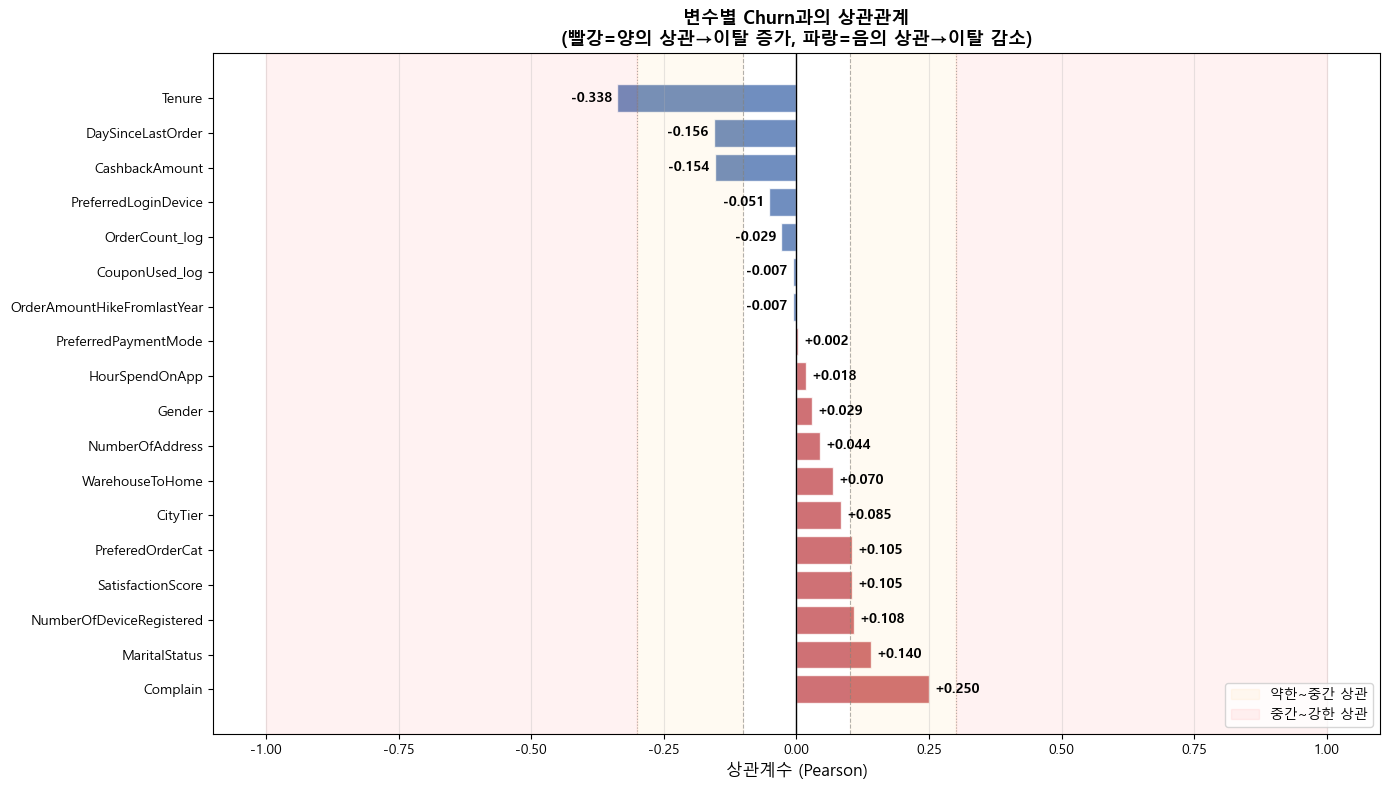


📋 Churn 상관관계 요약:
Complain                       0.250
MaritalStatus                  0.140
NumberOfDeviceRegistered       0.108
SatisfactionScore              0.105
PreferedOrderCat               0.105
CityTier                       0.085
WarehouseToHome                0.070
NumberOfAddress                0.044
Gender                         0.029
HourSpendOnApp                 0.018
PreferredPaymentMode           0.002
OrderAmountHikeFromlastYear   -0.007
CouponUsed_log                -0.007
OrderCount_log                -0.029
PreferredLoginDevice          -0.051
CashbackAmount                -0.154
DaySinceLastOrder             -0.156
Tenure                        -0.338


In [21]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 2 — Churn 상관관계 바 차트】 Churn과의 상관관계 정렬
# ════════════════════════════════════════════════════════════════════

# Churn과의 상관계수 추출
churn_corr = corr_matrix["Churn"].drop("Churn").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))

# 색상 설정: 양의 상관(빨강) vs 음의 상관(파랑)
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in churn_corr.values]

bars = ax.barh(churn_corr.index, churn_corr.values, color=colors, alpha=0.8, edgecolor="white")

# 상관계수 값 텍스트
for bar, val in zip(bars, churn_corr.values):
    offset = 0.01 if val >= 0 else -0.01
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=10, fontweight="bold")

# 기준선
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(-0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(0.3, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.axvline(-0.3, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)

# 참조 영역 배경
ax.axvspan(0.1, 0.3, alpha=0.05, color="orange", label="약한~중간 상관")
ax.axvspan(-0.3, -0.1, alpha=0.05, color="orange")
ax.axvspan(0.3, 1.0, alpha=0.05, color="red", label="중간~강한 상관")
ax.axvspan(-1.0, -0.3, alpha=0.05, color="red")

ax.set_xlabel("상관계수 (Pearson)", fontsize=12)
ax.set_title("변수별 Churn과의 상관관계\n(빨강=양의 상관→이탈 증가, 파랑=음의 상관→이탈 감소)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📋 Churn 상관관계 요약:")
print(churn_corr.round(3).to_string())

## 🔗 변수 그룹핑 분석 — 상관관계 기반

**분석 목적:**
-
-
1. 그룹별 상관관계 히트맵 : 그룹핑된 변수들의 내부 상관관계
2. Churn 상관관계 바 차트 : Churn과의 상관관계 정렬

### 📌 그룹핑 기준

| 그룹명 | 포함 변수 | 논리적 연결고리 |
|---|---|---|
| **주문 활동성** | OrderCount, CouponUsed, DaySinceLastOrder | 고객의 주문 빈도 & 활동 주기 |
| **고객 충성도** | Tenure, CashbackAmount | 재직 기간 + 로열티 혜택 |
| **앱 사용 패턴** | HourSpendOnApp, NumberOfDeviceRegistered | 디바이스 & 이용 시간 |
| **주소/물류** | NumberOfAddress, WarehouseToHome, CityTier | 배송 관련 특성 |
| **고객 프로필** | Gender, MaritalStatus, SatisfactionScore | 인구통계학적 & 만족도 |
| **불만/품질** | Complain, OrderAmountHikeFromlastYear | 불만사항 & 가격민감도 |
| **결제/카테고리** | PreferredLoginDevice, PreferredPaymentMode, PreferedOrderCat | 결제 & 카테고리 선호 |

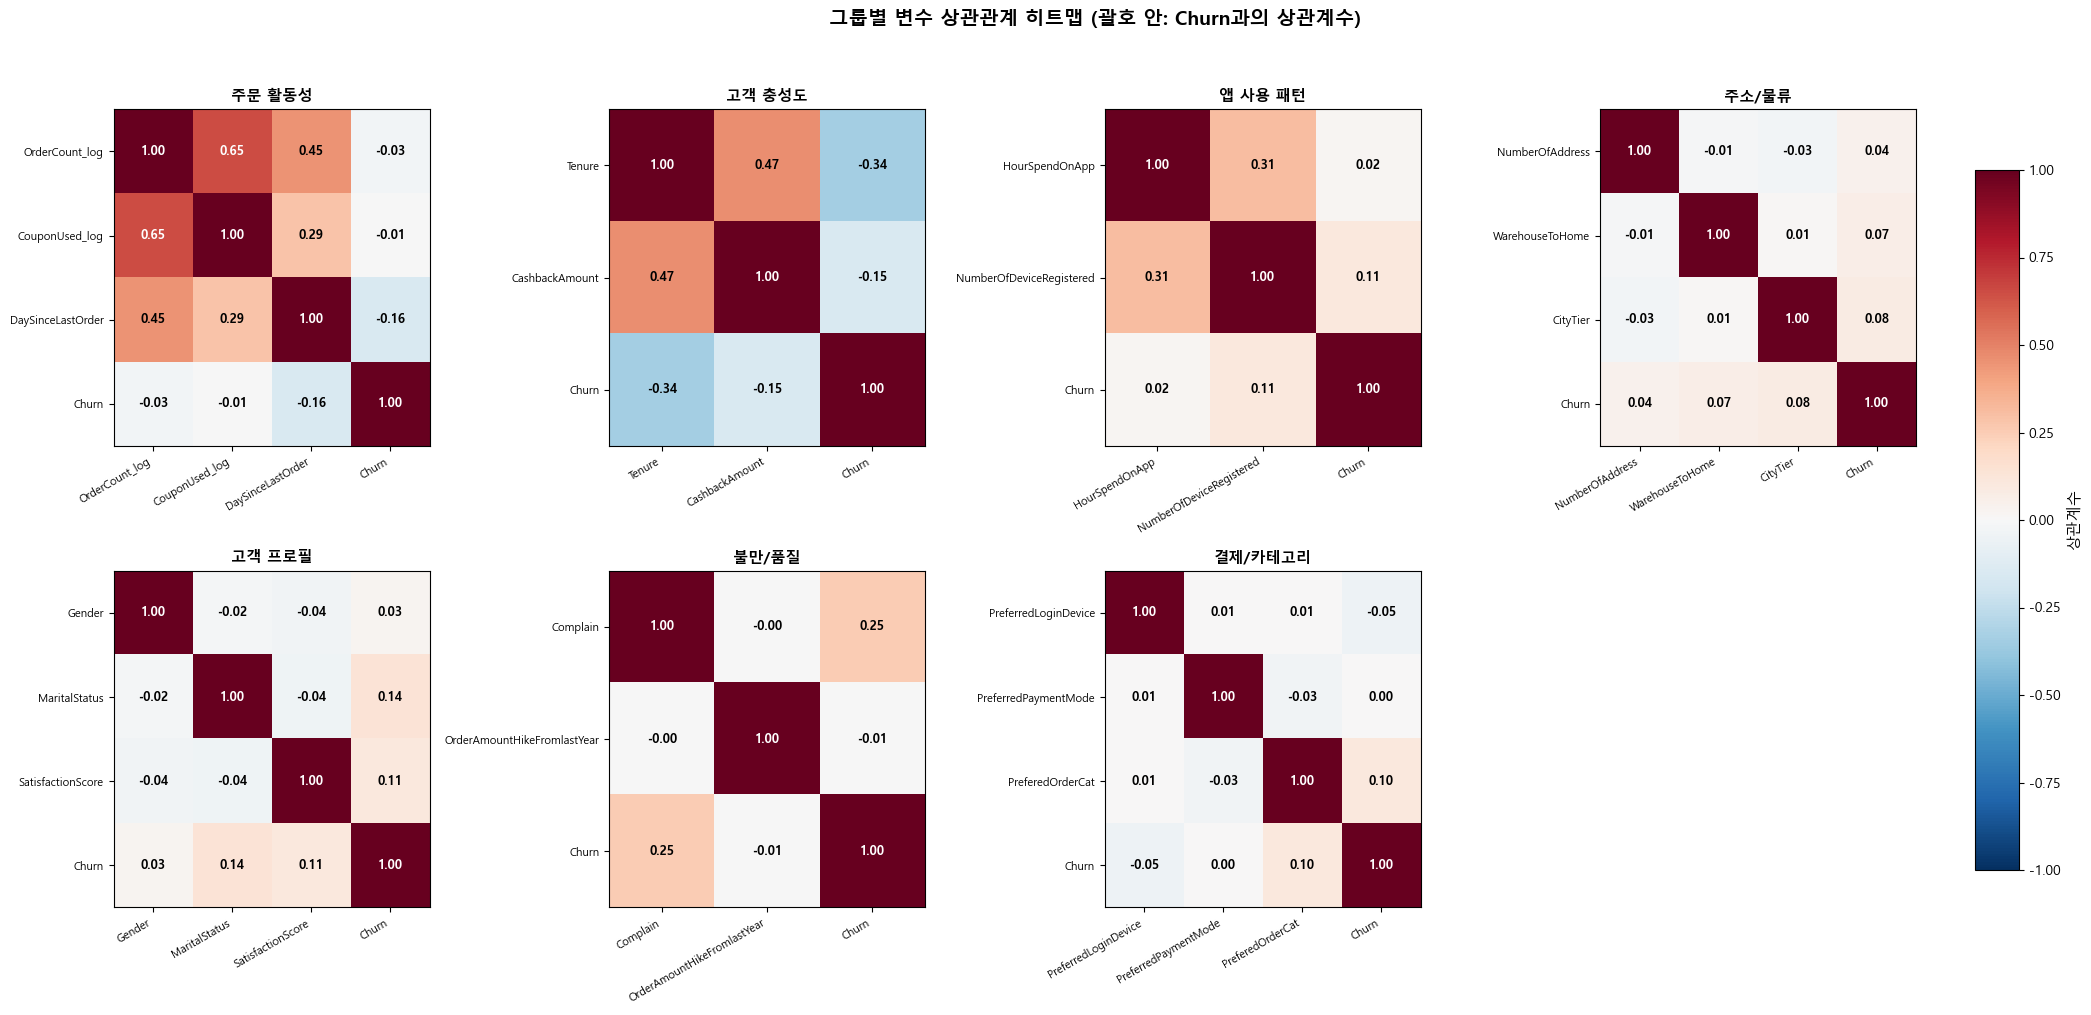

✅ Fig 6 저장: 그룹별 상관관계 히트맵


In [22]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 1 — 그룹별 상관관계 히트맵】 그룹핑된 변수들의 내부 상관관계
# ════════════════════════════════════════════════════════════════════

# 변수 그룹 정의
VAR_GROUPS = {
    "주문 활동성\n(OrderActivity)": ["OrderCount_log", "CouponUsed_log", "DaySinceLastOrder"],
    "고객 충성도\n(Loyalty)": ["Tenure", "CashbackAmount"],
    "앱 사용 패턴\n(AppUsage)": ["HourSpendOnApp", "NumberOfDeviceRegistered"],
    "주소/물류\n(Logistics)": ["NumberOfAddress", "WarehouseToHome", "CityTier"],
    "고객 프로필\n(Profile)": ["Gender", "MaritalStatus", "SatisfactionScore"],
    "불만/품질\n(Complaint)": ["Complain", "OrderAmountHikeFromlastYear"],
    "결제/카테고리\n(Payment)": ["PreferredLoginDevice", "PreferredPaymentMode", "PreferedOrderCat"],
}

# 그룹 내 변수 Flatten
all_group_vars = [v for grp in VAR_GROUPS.values() for v in grp]

# ── 1) 그룹별 상관관계 히트맵 (2×4 서브플롯) ────────────────────────
n_groups = len(VAR_GROUPS)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()

for idx, (grp_name, cols) in enumerate(VAR_GROUPS.items()):
    ax = axes_flat[idx]
    if len(cols) < 2:
        ax.set_visible(False)
        continue
    
    sub_corr = df_encoded_scaled[cols + ["Churn"]].corr()
    
    im = ax.imshow(sub_corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    
    ax.set_xticks(range(len(sub_corr.columns)))
    ax.set_yticks(range(len(sub_corr.columns)))
    ax.set_xticklabels(sub_corr.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(sub_corr.columns, fontsize=8)
    
    # 상관계수 텍스트
    for i in range(len(sub_corr.columns)):
        for j in range(len(sub_corr.columns)):
            val = sub_corr.values[i, j]
            if abs(val) > 0.5:
                text_color = "white"
            else:
                text_color = "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                   fontsize=9, color=text_color, fontweight="bold")
    
    # 그룹명에서 첫 줄만 추출 (제목용)
    title_short = grp_name.split("\n")[0]
    ax.set_title(title_short, fontsize=11, fontweight="bold")

# 마지막 셀 제거
for idx in range(n_groups, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# 컬러바
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("상관계수", fontsize=11)

fig.suptitle("그룹별 변수 상관관계 히트맵 (괄호 안: Churn과의 상관계수)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(rect=[0, 0, 0.88, 0.98])
plt.show()

print("✅ Fig 6 저장: 그룹별 상관관계 히트맵")

## 📊 그룹별 이탈률(Churn Rate) 분석

**분석 방법:** 각 그룹의 핵심 변수들을 기반으로 고객을 세그먼트화하고, 세그먼트별 이탈률을 비교합니다.

**활용 목적:**
- 이탈 위험이 높은 고객 세그먼트 식별
- 변수 그룹이 이탈에 미치는 종합적 영향 이해
- 마케팅/CRM 전략 수립을 위한 인사이트 도출

1. 그룹별 이탈률 비교 : 핵심 변수 기반 세그먼트별 이탈률

SMOTE

In [19]:
# %conda install -c conda-forge imbalanced-learn